In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
file_path = r"D:\UK_Insurance_Claims_Dataset.xlsx"

excel_file = pd.ExcelFile(file_path)

print("Available sheets:")
print(excel_file.sheet_names)

Available sheets:
['Fact_Claims', 'Dim_Customer', 'Dim_Policy', 'Dim_Region', 'Dim_ClaimType', 'Dim_Date']


In [3]:
fact_claims = pd.read_excel(file_path, sheet_name="Fact_Claims")
dim_customer = pd.read_excel(file_path, sheet_name="Dim_Customer")
dim_policy = pd.read_excel(file_path, sheet_name="Dim_Policy")
dim_region = pd.read_excel(file_path, sheet_name="Dim_Region")
dim_claimtype = pd.read_excel(file_path, sheet_name="Dim_ClaimType")
dim_date = pd.read_excel(file_path, sheet_name="Dim_Date")

In [4]:
tables = {
    "Fact Claims": fact_claims,
    "Customer": dim_customer,
    "Policy": dim_policy,
    "Region": dim_region,
    "Claim Type": dim_claimtype,
    "Date": dim_date
}

for name, df in tables.items():
    print(f"{name:15} : {df.shape[0]:,} rows × {df.shape[1]} columns")

Fact Claims     : 14,706 rows × 12 columns
Customer        : 3,000 rows × 7 columns
Policy          : 6,016 rows × 7 columns
Region          : 12 rows × 7 columns
Claim Type      : 8 rows × 10 columns
Date            : 4,383 rows × 12 columns


In [5]:
fact_claims.head()

,ClaimID,CustomerID,PolicyID,RegionID,ClaimTypeID,ClaimDate,SettlementDate,RequestedAmount_GBP,PaidAmount_GBP,ClaimStatus,Channel,DaysToSettle
0,CLM0000001,CUST101647,POL203340,8,1,2021-01-20,2021-03-04,6618.36,6618.36,Paid,Online,43.0
1,CLM0000002,CUST102234,POL204508,8,1,2021-01-14,2021-03-21,6405.30,6405.30,Paid,Online,66.0
2,CLM0000003,CUST101291,POL202638,7,1,2021-01-08,2021-01-22,3159.37,3159.37,Paid,Online,14.0
3,CLM0000004,CUST101374,POL202806,12,1,2021-01-31,2021-02-27,3724.31,3724.31,Paid,Broker,27.0
4,CLM0000005,CUST102631,POL205293,5,1,2021-01-04,2021-02-25,2040.30,2040.30,Paid,Online,52.0


In [6]:
fact_claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14706 entries, 0 to 14705
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ClaimID              14706 non-null  object        
 1   CustomerID           14706 non-null  object        
 2   PolicyID             14706 non-null  object        
 3   RegionID             14706 non-null  int64         
 4   ClaimTypeID          14706 non-null  int64         
 5   ClaimDate            14706 non-null  datetime64[ns]
 6   SettlementDate       14294 non-null  datetime64[ns]
 7   RequestedAmount_GBP  14706 non-null  float64       
 8   PaidAmount_GBP       14706 non-null  float64       
 9   ClaimStatus          14706 non-null  object        
 10  Channel              14706 non-null  object        
 11  DaysToSettle         14294 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(5)
memory usage: 1.3+ MB


In [7]:
fact_claims.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ClaimID,14706,14706,CLM0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,14706,2829,CUST100315,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PolicyID,14706,5183,POL205293,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RegionID,14706.0,NaN,NaN,NaN,5.401469,1.0,2.0,5.0,8.0,12.0,3.355789
ClaimTypeID,14706.0,NaN,NaN,NaN,2.996396,1.0,1.0,2.0,4.0,8.0,1.880533
ClaimDate,14706,NaN,NaN,NaN,2023-08-13 06:05:31.946144256,2021-01-01 00:00:00,2022-05-18 00:00:00,2023-09-07 12:00:00,2024-11-21 00:00:00,2025-12-31 00:00:00,NaN
SettlementDate,14294,NaN,NaN,NaN,2023-09-26 19:18:43.772211968,2021-01-11 00:00:00,2022-06-29 06:00:00,2023-10-20 00:00:00,2025-01-06 00:00:00,2026-06-02 00:00:00,NaN
RequestedAmount_GBP,14706.0,NaN,NaN,NaN,5316.755908,144.56,1407.685,3109.375,5932.5325,134966.64,7146.383038
PaidAmount_GBP,14706.0,NaN,NaN,NaN,4826.710164,0.0,1052.6775,2759.23,5515.1125,134966.64,6882.867018
ClaimStatus,14706,3,Paid,13365,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing = fact_claims.isnull().sum()

missing_percentage = (
    fact_claims.isnull().mean() * 100
).round(2)

data_quality = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_percentage
})

data_quality

,Missing Values,Missing %
ClaimID,0,0.0
CustomerID,0,0.0
PolicyID,0,0.0
RegionID,0,0.0
ClaimTypeID,0,0.0
ClaimDate,0,0.0
SettlementDate,412,2.8
RequestedAmount_GBP,0,0.0
PaidAmount_GBP,0,0.0
ClaimStatus,0,0.0


In [10]:
print("Total rows:", len(fact_claims))
print("Duplicate rows:", fact_claims.duplicated().sum())
print("Duplicate Claim IDs:", fact_claims["ClaimID"].duplicated().sum())

Total rows: 14706
Duplicate rows: 0
Duplicate Claim IDs: 0


In [11]:
fact_claims["ClaimDate"] = pd.to_datetime(
    fact_claims["ClaimDate"]
)

fact_claims["SettlementDate"] = pd.to_datetime(
    fact_claims["SettlementDate"]
)

dim_customer["CustomerSince"] = pd.to_datetime(
    dim_customer["CustomerSince"]
)

dim_policy["PolicyStartDate"] = pd.to_datetime(
    dim_policy["PolicyStartDate"]
)

dim_date["Date"] = pd.to_datetime(
    dim_date["Date"]
)

In [12]:
fact_claims.dtypes

ClaimID                        object
CustomerID                     object
PolicyID                       object
RegionID                        int64
ClaimTypeID                     int64
ClaimDate              datetime64[ns]
SettlementDate         datetime64[ns]
RequestedAmount_GBP           float64
PaidAmount_GBP                float64
ClaimStatus                    object
Channel                        object
DaysToSettle                  float64
dtype: object

In [13]:
total_claims = fact_claims["ClaimID"].nunique()

total_requested = fact_claims["RequestedAmount_GBP"].sum()

total_paid = fact_claims["PaidAmount_GBP"].sum()

avg_paid_claim = fact_claims["PaidAmount_GBP"].mean()

avg_settlement_days = fact_claims["DaysToSettle"].mean()

print(f"Total Claims          : {total_claims:,}")
print(f"Total Requested       : £{total_requested:,.2f}")
print(f"Total Paid            : £{total_paid:,.2f}")
print(f"Average Paid Claim    : £{avg_paid_claim:,.2f}")
print(f"Avg Settlement Days   : {avg_settlement_days:.2f}")

Total Claims          : 14,706
Total Requested       : £78,188,212.38
Total Paid            : £70,981,599.67
Average Paid Claim    : £4,826.71
Avg Settlement Days   : 45.31


In [14]:
claim_status = (
    fact_claims["ClaimStatus"]
    .value_counts()
    .to_frame("Claims")
)

claim_status["Percentage"] = (
    claim_status["Claims"] /
    claim_status["Claims"].sum() * 100
).round(2)

claim_status

,Claims,Percentage
ClaimStatus,,
Paid,13365,90.88
Rejected,929,6.32
In Review,412,2.80


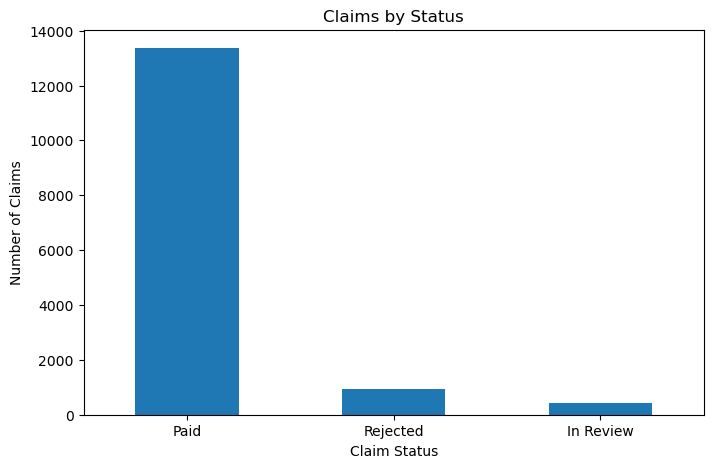

In [16]:
claim_status["Claims"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Claims by Status")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.show()

In [17]:
fact_claims["Year"] = fact_claims["ClaimDate"].dt.year

annual_claims = (
    fact_claims
    .groupby("Year")
    .agg(
        Claims=("ClaimID", "nunique"),
        Requested=("RequestedAmount_GBP", "sum"),
        Paid=("PaidAmount_GBP", "sum"),
        AvgClaim=("PaidAmount_GBP", "mean"),
        AvgSettlement=("DaysToSettle", "mean")
    )
    .reset_index()
)

annual_claims

,Year,Claims,Requested,Paid,AvgClaim,AvgSettlement
0,2021,2620,12182838.64,10959435.52,4182.990656,45.069412
1,2022,2771,13746950.38,12648922.36,4564.750040,45.275185
2,2023,2930,15242058.31,13836447.17,4722.336918,44.806180
3,2024,3102,17046583.59,15564679.29,5017.627108,45.993351
4,2025,3283,19969781.46,17972115.33,5474.296476,45.324028


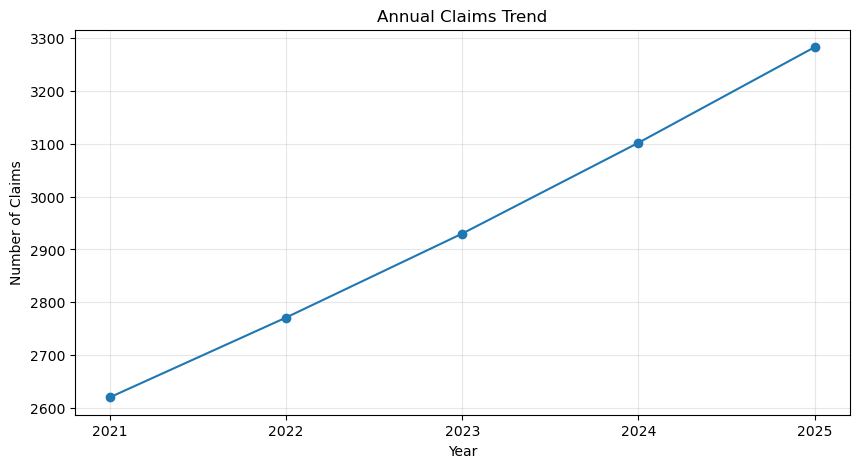

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    annual_claims["Year"].astype(int),
    annual_claims["Claims"],
    marker="o"
)

plt.title("Annual Claims Trend")
plt.xlabel("Year")
plt.ylabel("Number of Claims")
plt.xticks(annual_claims["Year"].astype(int))
plt.grid(alpha=0.3)

plt.show()

In [21]:
claim_frequency = (
    fact_claims
    .groupby("Year")
    .size()
    .reset_index(name="Claims")
)

claim_frequency

,Year,Claims
0,2021,2620
1,2022,2771
2,2023,2930
3,2024,3102
4,2025,3283


In [22]:
severity = (
    fact_claims
    .groupby("Year")
    .agg(
        Claims=("ClaimID", "nunique"),
        TotalPaid=("PaidAmount_GBP", "sum")
    )
    .reset_index()
)

severity["AverageSeverity"] = (
    severity["TotalPaid"] /
    severity["Claims"]
)

severity

,Year,Claims,TotalPaid,AverageSeverity
0,2021,2620,10959435.52,4182.990656
1,2022,2771,12648922.36,4564.750040
2,2023,2930,13836447.17,4722.336918
3,2024,3102,15564679.29,5017.627108
4,2025,3283,17972115.33,5474.296476


In [23]:
claims_analysis = fact_claims.merge(
    dim_claimtype[
        ["ClaimTypeID", "ClaimType", "Category", "Segment"]
    ],
    on="ClaimTypeID",
    how="left"
)

claims_analysis.head()

,ClaimID,CustomerID,PolicyID,RegionID,ClaimTypeID,ClaimDate,SettlementDate,RequestedAmount_GBP,PaidAmount_GBP,ClaimStatus,Channel,DaysToSettle,Year,ClaimType,Category,Segment
0,CLM0000001,CUST101647,POL203340,8,1,2021-01-20,2021-03-04,6618.36,6618.36,Paid,Online,43.0,2021,Motor,Vehicle,Individual
1,CLM0000002,CUST102234,POL204508,8,1,2021-01-14,2021-03-21,6405.30,6405.30,Paid,Online,66.0,2021,Motor,Vehicle,Individual
2,CLM0000003,CUST101291,POL202638,7,1,2021-01-08,2021-01-22,3159.37,3159.37,Paid,Online,14.0,2021,Motor,Vehicle,Individual
3,CLM0000004,CUST101374,POL202806,12,1,2021-01-31,2021-02-27,3724.31,3724.31,Paid,Broker,27.0,2021,Motor,Vehicle,Individual
4,CLM0000005,CUST102631,POL205293,5,1,2021-01-04,2021-02-25,2040.30,2040.30,Paid,Online,52.0,2021,Motor,Vehicle,Individual


In [24]:
claim_type_analysis = (
    claims_analysis
    .groupby("ClaimType")
    .agg(
        Claims=("ClaimID", "nunique"),
        Requested=("RequestedAmount_GBP", "sum"),
        Paid=("PaidAmount_GBP", "sum"),
        AvgClaim=("PaidAmount_GBP", "mean"),
        AvgSettlement=("DaysToSettle", "mean")
    )
    .reset_index()
)

claim_type_analysis.sort_values(
    "Paid",
    ascending=False
)

,ClaimType,Claims,Requested,Paid,AvgClaim,AvgSettlement
4,Life & Protection,1545,26595891.06,25844691.38,16727.955586,35.737769
5,Motor,4464,19893209.73,18244949.50,4087.130264,51.803719
3,Home/Property,2905,14177956.03,12513343.86,4307.519401,70.746714
1,Cyber,270,7260509.19,5552135.11,20563.463370,108.784314
2,Health/PMI,2300,4264789.96,3948077.34,1716.555365,17.515542
0,Agriculture,437,3529979.94,2758876.46,6313.218444,88.382775
6,Pet,1973,1858567.00,1596865.37,809.359032,18.445445
7,Travel,812,607309.47,522660.65,643.670751,37.413127


In [25]:
annual_claims["Claims_Growth_%"] = (
    annual_claims["Claims"].pct_change() * 100
)

annual_claims["Paid_Growth_%"] = (
    annual_claims["Paid"].pct_change() * 100
)

annual_claims["Severity_Growth_%"] = (
    annual_claims["AvgClaim"].pct_change() * 100
)

annual_claims.round(2)

,Year,Claims,Requested,Paid,AvgClaim,AvgSettlement,Claims_Growth_%,Paid_Growth_%,Severity_Growth_%
0,2021,2620,12182838.64,10959435.52,4182.99,45.07,NaN,NaN,NaN
1,2022,2771,13746950.38,12648922.36,4564.75,45.28,5.76,15.42,9.13
2,2023,2930,15242058.31,13836447.17,4722.34,44.81,5.74,9.39,3.45
3,2024,3102,17046583.59,15564679.29,5017.63,45.99,5.87,12.49,6.25
4,2025,3283,19969781.46,17972115.33,5474.30,45.32,5.83,15.47,9.10


In [26]:
start = annual_claims.iloc[0]
end = annual_claims.iloc[-1]

claims_change = (
    (end["Claims"] / start["Claims"]) - 1
) * 100

paid_change = (
    (end["Paid"] / start["Paid"]) - 1
) * 100

severity_change = (
    (end["AvgClaim"] / start["AvgClaim"]) - 1
) * 100

print(f"Claims growth:   {claims_change:.1f}%")
print(f"Paid growth:     {paid_change:.1f}%")
print(f"Severity growth: {severity_change:.1f}%")

Claims growth:   25.3%
Paid growth:     64.0%
Severity growth: 30.9%


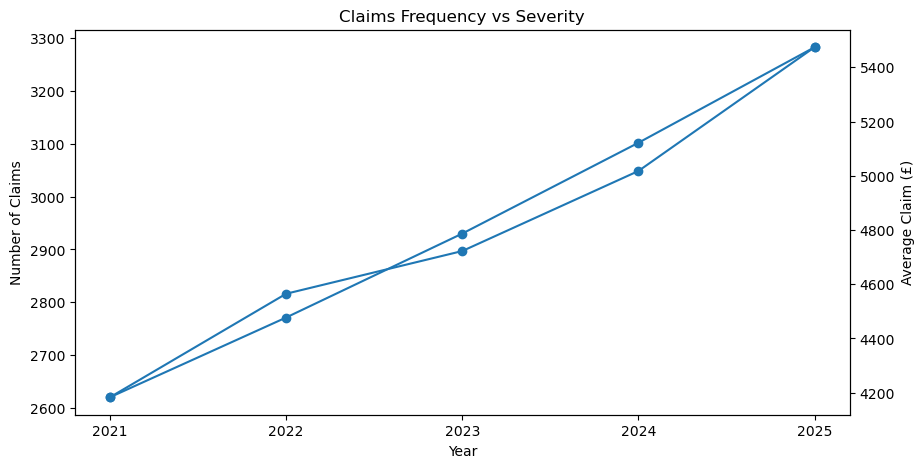

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    annual_claims["Year"],
    annual_claims["Claims"],
    marker="o",
    label="Claims"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Claims")

ax2 = ax1.twinx()

ax2.plot(
    annual_claims["Year"],
    annual_claims["AvgClaim"],
    marker="o",
    label="Average Claim"
)

ax2.set_ylabel("Average Claim (£)")

plt.title("Claims Frequency vs Severity")
plt.xticks(annual_claims["Year"].astype(int))
plt.show()

In [28]:
claim_type_analysis = (
    claims_analysis
    .groupby("ClaimType")
    .agg(
        Claims=("ClaimID", "nunique"),
        Requested=("RequestedAmount_GBP", "sum"),
        Paid=("PaidAmount_GBP", "sum"),
        AvgClaim=("PaidAmount_GBP", "mean"),
        AvgSettlement=("DaysToSettle", "mean")
    )
    .reset_index()
)

claim_type_analysis["Paid_Share_%"] = (
    claim_type_analysis["Paid"]
    / claim_type_analysis["Paid"].sum()
    * 100
)

claim_type_analysis.sort_values(
    "Paid",
    ascending=False
).round(2)

,ClaimType,Claims,Requested,Paid,AvgClaim,AvgSettlement,Paid_Share_%
4,Life & Protection,1545,26595891.06,25844691.38,16727.96,35.74,36.41
5,Motor,4464,19893209.73,18244949.50,4087.13,51.80,25.70
3,Home/Property,2905,14177956.03,12513343.86,4307.52,70.75,17.63
1,Cyber,270,7260509.19,5552135.11,20563.46,108.78,7.82
2,Health/PMI,2300,4264789.96,3948077.34,1716.56,17.52,5.56
0,Agriculture,437,3529979.94,2758876.46,6313.22,88.38,3.89
6,Pet,1973,1858567.00,1596865.37,809.36,18.45,2.25
7,Travel,812,607309.47,522660.65,643.67,37.41,0.74


### ML Project 1 — Claim Severity Prediction

In [37]:
ml_data = fact_claims.copy()

In [38]:
ml_data.columns.tolist()

['ClaimID',
 'CustomerID',
 'PolicyID',
 'RegionID',
 'ClaimTypeID',
 'ClaimDate',
 'SettlementDate',
 'RequestedAmount_GBP',
 'PaidAmount_GBP',
 'ClaimStatus',
 'Channel',
 'DaysToSettle',
 'Year']

In [39]:
print("CUSTOMER")
print(dim_customer.columns.tolist())

print("\nPOLICY")
print(dim_policy.columns.tolist())

print("\nREGION")
print(dim_region.columns.tolist())

print("\nCLAIM TYPE")
print(dim_claimtype.columns.tolist())

CUSTOMER
['CustomerID', 'CustomerName', 'Segment', 'Gender', 'AgeBand', 'RegionID', 'CustomerSince']

POLICY
['PolicyID', 'CustomerID', 'ClaimTypeID', 'RegionID', 'PolicyStartDate', 'AnnualPremium_GBP', 'SumInsured_GBP']

REGION
['RegionID', 'Region', 'Nation', 'AvgMotorPremium2026_GBP', 'AvgHomePremium2026_GBP', 'FloodRiskLevel', 'VolumeWeight']

CLAIM TYPE
['ClaimTypeID', 'ClaimType', 'Category', 'Segment', 'BaseAnnualVolume2021', 'VolumeCAGR', 'AvgAmount2021_GBP', 'AmountCAGR', 'ApprovalRate', 'SettleDaysRange']


In [40]:
# Start from Fact Claims
ml_data = fact_claims[
    [
        "ClaimID",
        "CustomerID",
        "PolicyID",
        "RegionID",
        "ClaimTypeID",
        "ClaimDate",
        "RequestedAmount_GBP",
        "PaidAmount_GBP",
        "Channel"
    ]
].copy()

# -----------------------------
# Customer features
# -----------------------------
customer_features = dim_customer[
    [
        "CustomerID",
        "Segment",
        "Gender",
        "AgeBand",
        "CustomerSince"
    ]
].copy()

ml_data = ml_data.merge(
    customer_features,
    on="CustomerID",
    how="left",
    validate="many_to_one"
)

# -----------------------------
# Policy features
# -----------------------------
policy_features = dim_policy[
    [
        "PolicyID",
        "PolicyStartDate",
        "AnnualPremium_GBP",
        "SumInsured_GBP"
    ]
].copy()

ml_data = ml_data.merge(
    policy_features,
    on="PolicyID",
    how="left",
    validate="many_to_one"
)

# -----------------------------
# Region features
# -----------------------------
region_features = dim_region[
    [
        "RegionID",
        "Region",
        "Nation",
        "FloodRiskLevel",
        "VolumeWeight"
    ]
].copy()

ml_data = ml_data.merge(
    region_features,
    on="RegionID",
    how="left",
    validate="many_to_one"
)

# -----------------------------
# Claim Type features
# -----------------------------
claimtype_features = dim_claimtype[
    [
        "ClaimTypeID",
        "ClaimType",
        "Category",
        "Segment"
    ]
].copy()

# Rename to avoid conflict with Customer Segment
claimtype_features = claimtype_features.rename(
    columns={"Segment": "ClaimSegment"}
)

ml_data = ml_data.merge(
    claimtype_features,
    on="ClaimTypeID",
    how="left",
    validate="many_to_one"
)

# -----------------------------
# Date features
# -----------------------------
ml_data["ClaimYear"] = ml_data["ClaimDate"].dt.year
ml_data["ClaimMonth"] = ml_data["ClaimDate"].dt.month
ml_data["ClaimQuarter"] = ml_data["ClaimDate"].dt.quarter
ml_data["ClaimMonthName"] = ml_data["ClaimDate"].dt.month_name()

# Policy tenure at time of claim
ml_data["PolicyTenureDays"] = (
    ml_data["ClaimDate"] - ml_data["PolicyStartDate"]
).dt.days

ml_data["PolicyTenureYears"] = (
    ml_data["PolicyTenureDays"] / 365.25
)

# Customer tenure at time of claim
ml_data["CustomerTenureDays"] = (
    ml_data["ClaimDate"] - ml_data["CustomerSince"]
).dt.days

ml_data["CustomerTenureYears"] = (
    ml_data["CustomerTenureDays"] / 365.25
)

print("ML dataset shape:", ml_data.shape)

display(ml_data.head())

ML dataset shape: (14706, 31)


,ClaimID,CustomerID,PolicyID,RegionID,ClaimTypeID,ClaimDate,RequestedAmount_GBP,PaidAmount_GBP,Channel,Segment,Gender,AgeBand,CustomerSince,PolicyStartDate,AnnualPremium_GBP,SumInsured_GBP,Region,Nation,FloodRiskLevel,VolumeWeight,ClaimType,Category,ClaimSegment,ClaimYear,ClaimMonth,ClaimQuarter,ClaimMonthName,PolicyTenureDays,PolicyTenureYears,CustomerTenureDays,CustomerTenureYears
0,CLM0000001,CUST101647,POL203340,8,1,2021-01-20,6618.36,6618.36,Online,Individual,Male,35-44,2021-01-06,2021-05-02,522.98,33849.34,Yorkshire and The Humber,England,Medium,0.082927,Motor,Vehicle,Individual,2021,1,1,January,-102,-0.279261,14,0.038330
1,CLM0000002,CUST102234,POL204508,8,1,2021-01-14,6405.30,6405.30,Online,Individual,Male,18-24,2021-02-26,2024-10-06,541.82,29463.68,Yorkshire and The Humber,England,Medium,0.082927,Motor,Vehicle,Individual,2021,1,1,January,-1361,-3.726215,-43,-0.117728
2,CLM0000003,CUST101291,POL202638,7,1,2021-01-08,3159.37,3159.37,Online,Individual,Male,55-64,2019-11-21,2022-01-06,623.16,14545.39,North West,England,Medium,0.107317,Motor,Vehicle,Individual,2021,1,1,January,-363,-0.993840,414,1.133470
3,CLM0000004,CUST101374,POL202806,12,1,2021-01-31,3724.31,3724.31,Broker,Individual,Female,18-24,2017-05-09,2024-10-23,703.00,23159.35,Northern Ireland,Northern Ireland,High,0.029268,Motor,Vehicle,Individual,2021,1,1,January,-1361,-3.726215,1363,3.731691
4,CLM0000005,CUST102631,POL205293,5,1,2021-01-04,2040.30,2040.30,Online,Individual,Male,25-34,2015-10-02,2023-03-27,751.21,16092.71,West Midlands,England,Medium,0.087805,Motor,Vehicle,Individual,2021,1,1,January,-812,-2.223135,1921,5.259411


In [41]:
ml_data.columns.tolist()

['ClaimID',
 'CustomerID',
 'PolicyID',
 'RegionID',
 'ClaimTypeID',
 'ClaimDate',
 'RequestedAmount_GBP',
 'PaidAmount_GBP',
 'Channel',
 'Segment',
 'Gender',
 'AgeBand',
 'CustomerSince',
 'PolicyStartDate',
 'AnnualPremium_GBP',
 'SumInsured_GBP',
 'Region',
 'Nation',
 'FloodRiskLevel',
 'VolumeWeight',
 'ClaimType',
 'Category',
 'ClaimSegment',
 'ClaimYear',
 'ClaimMonth',
 'ClaimQuarter',
 'ClaimMonthName',
 'PolicyTenureDays',
 'PolicyTenureYears',
 'CustomerTenureDays',
 'CustomerTenureYears']

In [42]:
# Features for claim severity prediction

features = [
    "RequestedAmount_GBP",
    "AnnualPremium_GBP",
    "SumInsured_GBP",
    "PolicyTenureYears",
    "CustomerTenureYears",
    "Segment",
    "Gender",
    "AgeBand",
    "Region",
    "Nation",
    "FloodRiskLevel",
    "VolumeWeight",
    "ClaimType",
    "Category",
    "ClaimSegment",
    "Channel",
    "ClaimYear",
    "ClaimMonth",
    "ClaimQuarter"
]

target = "PaidAmount_GBP"

X = ml_data[features].copy()
y = ml_data[target].copy()

print("Features:", X.shape)
print("Target:", y.shape)

display(X.head())

Features: (14706, 19)
Target: (14706,)


,RequestedAmount_GBP,AnnualPremium_GBP,SumInsured_GBP,PolicyTenureYears,CustomerTenureYears,Segment,Gender,AgeBand,Region,Nation,FloodRiskLevel,VolumeWeight,ClaimType,Category,ClaimSegment,Channel,ClaimYear,ClaimMonth,ClaimQuarter
0,6618.36,522.98,33849.34,-0.279261,0.038330,Individual,Male,35-44,Yorkshire and The Humber,England,Medium,0.082927,Motor,Vehicle,Individual,Online,2021,1,1
1,6405.30,541.82,29463.68,-3.726215,-0.117728,Individual,Male,18-24,Yorkshire and The Humber,England,Medium,0.082927,Motor,Vehicle,Individual,Online,2021,1,1
2,3159.37,623.16,14545.39,-0.993840,1.133470,Individual,Male,55-64,North West,England,Medium,0.107317,Motor,Vehicle,Individual,Online,2021,1,1
3,3724.31,703.00,23159.35,-3.726215,3.731691,Individual,Female,18-24,Northern Ireland,Northern Ireland,High,0.029268,Motor,Vehicle,Individual,Broker,2021,1,1
4,2040.30,751.21,16092.71,-2.223135,5.259411,Individual,Male,25-34,West Midlands,England,Medium,0.087805,Motor,Vehicle,Individual,Online,2021,1,1


In [43]:
X.isnull().sum().sort_values(ascending=False).head(10)

SumInsured_GBP         3112
Gender                 1611
AgeBand                1611
RequestedAmount_GBP       0
VolumeWeight              0
ClaimMonth                0
ClaimYear                 0
Channel                   0
ClaimSegment              0
Category                  0
dtype: int64

In [44]:
y.isnull().sum()

0

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 11764
Testing rows: 2942


In [46]:
numeric_features = [
    "RequestedAmount_GBP",
    "AnnualPremium_GBP",
    "SumInsured_GBP",
    "PolicyTenureYears",
    "CustomerTenureYears",
    "VolumeWeight",
    "ClaimYear",
    "ClaimMonth",
    "ClaimQuarter"
]

categorical_features = [
    "Segment",
    "Gender",
    "AgeBand",
    "Region",
    "Nation",
    "FloodRiskLevel",
    "ClaimType",
    "Category",
    "ClaimSegment",
    "Channel"
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 9
Categorical features: 10


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [48]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline: predict the training-set average for every test claim
baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("BASELINE MODEL")
print("-------------------------")
print(f"MAE  : £{baseline_mae:,.2f}")
print(f"RMSE : £{baseline_rmse:,.2f}")
print(f"R²   : {baseline_r2:.4f}")

BASELINE MODEL
-------------------------
MAE  : £4,145.07
RMSE : £6,683.43
R²   : -0.0000


In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [50]:
rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

TypeError: Encoders require their input to be uniformly strings or numbers. Got ['int', 'str']

In [51]:
for col in categorical_features:
    types = X_train[col].dropna().map(type).value_counts()
    
    if len(types) > 1:
        print(f"\nMixed types found in: {col}")
        print(types)


Mixed types found in: Segment
Segment
<class 'str'>    11755
<class 'int'>        9
Name: count, dtype: int64


In [52]:
X_train_fixed = X_train.copy()
X_test_fixed = X_test.copy()

for col in categorical_features:
    X_train_fixed[col] = X_train_fixed[col].astype("string")
    X_test_fixed[col] = X_test_fixed[col].astype("string")

print("Categorical features converted to consistent string type.")

Categorical features converted to consistent string type.


In [53]:
rf_model.fit(X_train_fixed, y_train)

print("Random Forest training completed successfully.")

TypeError: boolean value of NA is ambiguous

In [54]:
import numpy as np

X_train_fixed = X_train.copy()
X_test_fixed = X_test.copy()

for col in categorical_features:
    X_train_fixed[col] = X_train_fixed[col].where(
        X_train_fixed[col].notna(),
        np.nan
    ).astype(object)

    X_test_fixed[col] = X_test_fixed[col].where(
        X_test_fixed[col].notna(),
        np.nan
    ).astype(object)

print("Categorical columns standardized.")

Categorical columns standardized.


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor rebuilt successfully.")

Preprocessor rebuilt successfully.


In [56]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline ready.")

Random Forest pipeline ready.


In [57]:
rf_model.fit(X_train_fixed, y_train)

print("Random Forest training completed successfully.")

TypeError: Encoders require their input to be uniformly strings or numbers. Got ['int', 'str']

In [58]:
import numpy as np

X_train_fixed = X_train.copy()
X_test_fixed = X_test.copy()

for col in categorical_features:
    # Convert everything to string, including missing values
    X_train_fixed[col] = X_train_fixed[col].fillna("Missing").astype(str)
    X_test_fixed[col] = X_test_fixed[col].fillna("Missing").astype(str)

print("Categorical columns standardized successfully.")

Categorical columns standardized successfully.


In [59]:
for col in categorical_features:
    unique_types = X_train_fixed[col].map(type).nunique()
    
    if unique_types > 1:
        print("Mixed types:", col)
        
print("Type check completed.")

Type check completed.


In [60]:
categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [61]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [63]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [64]:
rf_model.fit(X_train_fixed, y_train)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [65]:
y_pred = rf_model.predict(X_test_fixed)

rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

print("RANDOM FOREST MODEL")
print("-------------------------")
print(f"MAE  : £{rf_mae:,.2f}")
print(f"RMSE : £{rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

RANDOM FOREST MODEL
-------------------------
MAE  : £838.50
RMSE : £2,571.71
R²   : 0.8519


In [66]:
# Get the fitted preprocessing pipeline
fitted_preprocessor = rf_model.named_steps["preprocessor"]

# Get the trained Random Forest
rf = rf_model.named_steps["model"]

# Get feature names after one-hot encoding
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance
importance = rf.feature_importances_

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort descending
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

# Show top 20
display(feature_importance.head(20))

,Feature,Importance
0,num__RequestedAmount_GBP,0.938349
1,num__AnnualPremium_GBP,0.015334
2,num__SumInsured_GBP,0.011325
3,num__PolicyTenureYears,0.006935
4,num__CustomerTenureYears,0.006282
5,num__VolumeWeight,0.003644
6,num__ClaimMonth,0.003017
7,num__ClaimYear,0.001858
8,cat__FloodRiskLevel_High,0.001348
9,cat__Channel_Online,0.001248


In [67]:
features_no_requested = [
    "AnnualPremium_GBP",
    "SumInsured_GBP",
    "PolicyTenureYears",
    "CustomerTenureYears",
    "Segment",
    "Gender",
    "AgeBand",
    "Region",
    "Nation",
    "FloodRiskLevel",
    "VolumeWeight",
    "ClaimType",
    "Category",
    "ClaimSegment",
    "Channel",
    "ClaimYear",
    "ClaimMonth",
    "ClaimQuarter"
]

X2 = ml_data[features_no_requested].copy()
y2 = ml_data["PaidAmount_GBP"].copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

numeric_features_2 = [
    "AnnualPremium_GBP",
    "SumInsured_GBP",
    "PolicyTenureYears",
    "CustomerTenureYears",
    "VolumeWeight",
    "ClaimYear",
    "ClaimMonth",
    "ClaimQuarter"
]

categorical_features_2 = [
    "Segment",
    "Gender",
    "AgeBand",
    "Region",
    "Nation",
    "FloodRiskLevel",
    "ClaimType",
    "Category",
    "ClaimSegment",
    "Channel"
]

# Standardize categorical columns
for col in categorical_features_2:
    X2_train[col] = X2_train[col].fillna("Missing").astype(str)
    X2_test[col] = X2_test[col].fillna("Missing").astype(str)

In [68]:
numeric_transformer_2 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer_2 = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor_2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_2, numeric_features_2),
        ("cat", categorical_transformer_2, categorical_features_2)
    ]
)

In [69]:
rf_model_2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_2),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [70]:
rf_model_2.fit(X2_train, y2_train)

y2_pred = rf_model_2.predict(X2_test)

mae_2 = mean_absolute_error(y2_test, y2_pred)
rmse_2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2 = r2_score(y2_test, y2_pred)

print("RANDOM FOREST — WITHOUT REQUESTED AMOUNT")
print("------------------------------------------")
print(f"MAE  : £{mae_2:,.2f}")
print(f"RMSE : £{rmse_2:,.2f}")
print(f"R²   : {r2_2:.4f}")

RANDOM FOREST — WITHOUT REQUESTED AMOUNT
------------------------------------------
MAE  : £2,477.26
RMSE : £4,661.86
R²   : 0.5134


In [71]:
# Extract feature importance from Model 2

fitted_preprocessor_2 = rf_model_2.named_steps["preprocessor"]
rf_2 = rf_model_2.named_steps["model"]

feature_names_2 = fitted_preprocessor_2.get_feature_names_out()
importance_2 = rf_2.feature_importances_

feature_importance_2 = pd.DataFrame({
    "Feature": feature_names_2,
    "Importance": importance_2
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_2.head(25))

,Feature,Importance
0,cat__Category_Protection,0.243001
1,cat__ClaimType_Life & Protection,0.219989
2,num__AnnualPremium_GBP,0.081084
3,num__SumInsured_GBP,0.067843
4,cat__ClaimType_Cyber,0.066102
5,num__PolicyTenureYears,0.060809
6,cat__Category_Commercial,0.060258
7,num__CustomerTenureYears,0.047337
8,num__ClaimYear,0.022550
9,num__ClaimMonth,0.021975


In [72]:
def get_business_feature(feature):
    feature = feature.replace("num__", "")
    feature = feature.replace("cat__", "")
    
    for col in categorical_features_2:
        if feature.startswith(col + "_"):
            return col
    
    for col in numeric_features_2:
        if feature == col:
            return col
    
    return feature


feature_importance_2["BusinessFeature"] = (
    feature_importance_2["Feature"]
    .apply(get_business_feature)
)

business_importance = (
    feature_importance_2
    .groupby("BusinessFeature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

business_importance["ImportancePct"] = (
    business_importance["Importance"] * 100
)

display(business_importance)

,BusinessFeature,Importance,ImportancePct
0,Category,0.322219,32.221861
1,ClaimType,0.302120,30.212013
2,AnnualPremium_GBP,0.081084,8.108439
3,SumInsured_GBP,0.067843,6.784336
4,PolicyTenureYears,0.060809,6.080888
5,CustomerTenureYears,0.047337,4.733664
6,ClaimYear,0.022550,2.254974
7,ClaimMonth,0.021975,2.197533
8,VolumeWeight,0.016853,1.685327
9,Region,0.015581,1.558063


In [73]:
claim_type_analysis = (
    ml_data
    .groupby(["Category", "ClaimType"])
    .agg(
        Claims=("ClaimID", "nunique"),
        Requested=("RequestedAmount_GBP", "sum"),
        Paid=("PaidAmount_GBP", "sum"),
        AvgRequested=("RequestedAmount_GBP", "mean"),
        AvgPaid=("PaidAmount_GBP", "mean")
    )
    .reset_index()
)

claim_type_analysis["SettlementRate"] = (
    claim_type_analysis["Paid"] /
    claim_type_analysis["Requested"]
)

claim_type_analysis["PaidShare"] = (
    claim_type_analysis["Paid"] /
    claim_type_analysis["Paid"].sum()
)

claim_type_analysis = claim_type_analysis.sort_values(
    "AvgPaid",
    ascending=False
)

display(claim_type_analysis)

,Category,ClaimType,Claims,Requested,Paid,AvgRequested,AvgPaid,SettlementRate,PaidShare
1,Commercial,Cyber,270,7260509.19,5552135.11,26890.774778,20563.463370,0.764703,0.078219
5,Protection,Life & Protection,1545,26595891.06,25844691.38,17214.168971,16727.955586,0.971755,0.364104
0,Agriculture,Agriculture,437,3529979.94,2758876.46,8077.757300,6313.218444,0.781556,0.038867
4,Property,Home/Property,2905,14177956.03,12513343.86,4880.535639,4307.519401,0.882592,0.176290
7,Vehicle,Motor,4464,19893209.73,18244949.50,4456.364187,4087.130264,0.917145,0.257038
2,Health,Health/PMI,2300,4264789.96,3948077.34,1854.256504,1716.555365,0.925738,0.055621
3,Pet,Pet,1973,1858567.00,1596865.37,942.000507,809.359032,0.859192,0.022497
6,Travel,Travel,812,607309.47,522660.65,747.918067,643.670751,0.860617,0.007363


In [74]:
risk_matrix = (
    claim_type_analysis[
        [
            "Category",
            "ClaimType",
            "Claims",
            "AvgPaid",
            "Paid",
            "PaidShare",
            "SettlementRate"
        ]
    ]
    .copy()
)

# Frequency share
risk_matrix["FrequencyShare"] = (
    risk_matrix["Claims"] /
    risk_matrix["Claims"].sum()
)

# Normalize frequency and severity to 0-100
risk_matrix["FrequencyScore"] = (
    risk_matrix["FrequencyShare"] /
    risk_matrix["FrequencyShare"].max()
) * 100

risk_matrix["SeverityScore"] = (
    risk_matrix["AvgPaid"] /
    risk_matrix["AvgPaid"].max()
) * 100

# Combined frequency × severity score
risk_matrix["RiskScore"] = (
    risk_matrix["FrequencyScore"] *
    risk_matrix["SeverityScore"]
) ** 0.5

risk_matrix = risk_matrix.sort_values(
    "RiskScore",
    ascending=False
).reset_index(drop=True)

display(risk_matrix)

,Category,ClaimType,Claims,AvgPaid,Paid,PaidShare,SettlementRate,FrequencyShare,FrequencyScore,SeverityScore,RiskScore
0,Protection,Life & Protection,1545,16727.955586,25844691.38,0.364104,0.971755,0.105059,34.610215,81.347948,53.061003
1,Vehicle,Motor,4464,4087.130264,18244949.50,0.257038,0.917145,0.303550,100.000000,19.875690,44.582160
2,Property,Home/Property,2905,4307.519401,12513343.86,0.176290,0.882592,0.197538,65.076165,20.947441,36.921256
3,Commercial,Cyber,270,20563.463370,5552135.11,0.078219,0.764703,0.018360,6.048387,100.000000,24.593469
4,Health,Health/PMI,2300,1716.555365,3948077.34,0.055621,0.925738,0.156399,51.523297,8.347599,20.738751
5,Agriculture,Agriculture,437,6313.218444,2758876.46,0.038867,0.781556,0.029716,9.789427,30.701144,17.336280
6,Pet,Pet,1973,809.359032,1596865.37,0.022497,0.859192,0.134163,44.198029,3.935908,13.189366
7,Travel,Travel,812,643.670751,522660.65,0.007363,0.860617,0.055216,18.189964,3.130167,7.545702


In [75]:
anomaly_data = ml_data.copy()

# Claim settlement ratio
anomaly_data["SettlementRatio"] = (
    anomaly_data["PaidAmount_GBP"] /
    anomaly_data["RequestedAmount_GBP"]
)

# Requested amount relative to sum insured
anomaly_data["RequestToSumInsured"] = (
    anomaly_data["RequestedAmount_GBP"] /
    anomaly_data["SumInsured_GBP"]
)

# Paid amount relative to sum insured
anomaly_data["PaidToSumInsured"] = (
    anomaly_data["PaidAmount_GBP"] /
    anomaly_data["SumInsured_GBP"]
)

# Add DaysToSettle from original fact table
anomaly_data["DaysToSettle"] = fact_claims["DaysToSettle"].values

# Select anomaly features
anomaly_features = [
    "RequestedAmount_GBP",
    "PaidAmount_GBP",
    "SettlementRatio",
    "RequestToSumInsured",
    "PaidToSumInsured",
    "AnnualPremium_GBP",
    "SumInsured_GBP",
    "DaysToSettle"
]

display(anomaly_data[anomaly_features].describe())

,RequestedAmount_GBP,PaidAmount_GBP,SettlementRatio,RequestToSumInsured,PaidToSumInsured,AnnualPremium_GBP,SumInsured_GBP,DaysToSettle
count,14706.000000,14706.000000,14706.000000,11594.000000,11594.000000,14706.000000,1.159400e+04,14294.000000
mean,5316.755908,4826.710164,0.908813,0.144929,0.131194,647.477936,2.392055e+05,45.307052
std,7146.383038,6882.867018,0.287885,0.172806,0.168408,799.145303,5.230017e+05,30.404815
min,144.560000,0.000000,0.000000,0.001129,0.000000,44.020000,2.018480e+03,5.000000
25%,1407.685000,1052.677500,1.000000,0.019956,0.013064,253.960000,1.387048e+04,21.000000
50%,3109.375000,2759.230000,1.000000,0.093437,0.077525,463.695000,3.156828e+04,37.000000
75%,5932.532500,5515.112500,1.000000,0.202243,0.186765,744.170000,3.206416e+05,64.000000
max,134966.640000,134966.640000,1.000000,2.104239,2.104239,5907.810000,4.956998e+06,180.000000


In [76]:
anomaly_model_data = anomaly_data[
    anomaly_features
].dropna().copy()

print("Original claims:", len(anomaly_data))
print("Claims available for anomaly detection:", len(anomaly_model_data))
print("Excluded claims:", len(anomaly_data) - len(anomaly_model_data))

Original claims: 14706
Claims available for anomaly detection: 11265
Excluded claims: 3441


In [77]:
print(anomaly_model_data.isnull().sum())

RequestedAmount_GBP    0
PaidAmount_GBP         0
SettlementRatio        0
RequestToSumInsured    0
PaidToSumInsured       0
AnnualPremium_GBP      0
SumInsured_GBP         0
DaysToSettle           0
dtype: int64


In [78]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(anomaly_model_data)

print("Isolation Forest training completed.")

Isolation Forest training completed.


In [79]:
anomaly_model_data["AnomalyScore"] = (
    isolation_forest.decision_function(
        anomaly_model_data[anomaly_features]
    )
)

anomaly_model_data["AnomalyFlag"] = (
    isolation_forest.predict(
        anomaly_model_data[anomaly_features]
    ) == -1
)

print(
    "Anomalies detected:",
    anomaly_model_data["AnomalyFlag"].sum()
)

print(
    "Anomaly rate:",
    f"{anomaly_model_data['AnomalyFlag'].mean() * 100:.2f}%"
)

Anomalies detected: 226
Anomaly rate: 2.01%


In [80]:
# Create an index linking anomaly rows back to the original ML dataset
anomaly_input = anomaly_data[
    ["ClaimID"] + anomaly_features
].dropna().copy()

# Add model results
anomaly_input["AnomalyScore"] = (
    isolation_forest.decision_function(
        anomaly_input[anomaly_features]
    )
)

anomaly_input["AnomalyFlag"] = (
    isolation_forest.predict(
        anomaly_input[anomaly_features]
    ) == -1
)

print("Anomaly result rows:", len(anomaly_input))

Anomaly result rows: 11265


In [81]:
top_anomalies = anomaly_input[
    anomaly_input["AnomalyFlag"] == True
].sort_values(
    "AnomalyScore",
    ascending=True
)

display(top_anomalies.head(20))

,ClaimID,RequestedAmount_GBP,PaidAmount_GBP,SettlementRatio,RequestToSumInsured,PaidToSumInsured,AnnualPremium_GBP,SumInsured_GBP,DaysToSettle,AnomalyScore,AnomalyFlag
14442,CLM0014443,64231.04,0.00,0.0,0.018142,0.000000,4998.25,3540545.61,168.0,-0.117870,True
14660,CLM0014661,57697.99,0.00,0.0,0.011836,0.000000,5267.30,4874898.46,124.0,-0.112674,True
14649,CLM0014650,61390.99,61390.99,1.0,0.012593,0.012593,5267.30,4874898.46,81.0,-0.103683,True
14464,CLM0014465,59579.08,0.00,0.0,0.014038,0.000000,5019.46,4244034.19,115.0,-0.102817,True
14623,CLM0014624,52865.50,52865.50,1.0,0.011554,0.011554,5152.07,4575622.56,131.0,-0.101288,True
14573,CLM0014574,58147.88,58147.88,1.0,0.021172,0.021172,5798.61,2746469.53,139.0,-0.100473,True
14577,CLM0014578,14869.50,0.00,0.0,0.003370,0.000000,5584.48,4412059.11,170.0,-0.099825,True
14678,CLM0014679,89170.03,0.00,0.0,0.034619,0.000000,3958.72,2575725.89,175.0,-0.098946,True
14453,CLM0014454,41828.27,0.00,0.0,0.009630,0.000000,4139.24,4343498.23,141.0,-0.095905,True
14702,CLM0014703,68784.13,0.00,0.0,0.046137,0.000000,4926.88,1490873.10,160.0,-0.095786,True


In [82]:
# Thresholds based on the 95th percentile
request_threshold = anomaly_input["RequestedAmount_GBP"].quantile(0.95)
paid_threshold = anomaly_input["PaidAmount_GBP"].quantile(0.95)
settlement_threshold = anomaly_input["DaysToSettle"].quantile(0.95)
request_sum_threshold = anomaly_input["RequestToSumInsured"].quantile(0.95)

anomaly_input["HighRequestedAmount"] = (
    anomaly_input["RequestedAmount_GBP"] >= request_threshold
)

anomaly_input["HighPaidAmount"] = (
    anomaly_input["PaidAmount_GBP"] >= paid_threshold
)

anomaly_input["LongSettlement"] = (
    anomaly_input["DaysToSettle"] >= settlement_threshold
)

anomaly_input["HighRequestToSumInsured"] = (
    anomaly_input["RequestToSumInsured"] >= request_sum_threshold
)

print("Thresholds:")
print(f"High requested amount : £{request_threshold:,.2f}")
print(f"High paid amount      : £{paid_threshold:,.2f}")
print(f"Long settlement       : {settlement_threshold:.0f} days")
print(f"High request / SI     : {request_sum_threshold:.2f}")

Thresholds:
High requested amount : £21,110.83
High paid amount      : £20,621.76
Long settlement       : 111 days
High request / SI     : 0.47


In [83]:
investigation_flags = [
    "HighRequestedAmount",
    "HighPaidAmount",
    "LongSettlement",
    "HighRequestToSumInsured"
]

anomaly_input["InvestigationIndicatorCount"] = (
    anomaly_input[investigation_flags]
    .sum(axis=1)
)

display(
    anomaly_input[
        anomaly_input["AnomalyFlag"] == True
    ][
        [
            "ClaimID",
            "RequestedAmount_GBP",
            "PaidAmount_GBP",
            "SettlementRatio",
            "RequestToSumInsured",
            "DaysToSettle",
            "AnomalyScore",
            "HighRequestedAmount",
            "HighPaidAmount",
            "LongSettlement",
            "HighRequestToSumInsured",
            "InvestigationIndicatorCount"
        ]
    ].sort_values(
        "AnomalyScore"
    ).head(20)
)

,ClaimID,RequestedAmount_GBP,PaidAmount_GBP,SettlementRatio,RequestToSumInsured,DaysToSettle,AnomalyScore,HighRequestedAmount,HighPaidAmount,LongSettlement,HighRequestToSumInsured,InvestigationIndicatorCount
14442,CLM0014443,64231.04,0.00,0.0,0.018142,168.0,-0.117870,True,False,True,False,2
14660,CLM0014661,57697.99,0.00,0.0,0.011836,124.0,-0.112674,True,False,True,False,2
14649,CLM0014650,61390.99,61390.99,1.0,0.012593,81.0,-0.103683,True,True,False,False,2
14464,CLM0014465,59579.08,0.00,0.0,0.014038,115.0,-0.102817,True,False,True,False,2
14623,CLM0014624,52865.50,52865.50,1.0,0.011554,131.0,-0.101288,True,True,True,False,3
14573,CLM0014574,58147.88,58147.88,1.0,0.021172,139.0,-0.100473,True,True,True,False,3
14577,CLM0014578,14869.50,0.00,0.0,0.003370,170.0,-0.099825,False,False,True,False,1
14678,CLM0014679,89170.03,0.00,0.0,0.034619,175.0,-0.098946,True,False,True,False,2
14453,CLM0014454,41828.27,0.00,0.0,0.009630,141.0,-0.095905,True,False,True,False,2
14702,CLM0014703,68784.13,0.00,0.0,0.046137,160.0,-0.095786,True,False,True,False,2


In [84]:
# Create business-readable investigation reasons

def get_investigation_reason(row):
    reasons = []

    if row["HighRequestedAmount"]:
        reasons.append("High Requested Amount")

    if row["HighPaidAmount"]:
        reasons.append("High Paid Amount")

    if row["LongSettlement"]:
        reasons.append("Long Settlement")

    if row["HighRequestToSumInsured"]:
        reasons.append("High Request / Sum Insured")

    if not reasons:
        reasons.append("Unusual Claim Pattern")

    return " | ".join(reasons)


anomaly_input["InvestigationReason"] = anomaly_input.apply(
    get_investigation_reason,
    axis=1
)

display(
    anomaly_input[
        anomaly_input["AnomalyFlag"]
    ][
        [
            "ClaimID",
            "RequestedAmount_GBP",
            "PaidAmount_GBP",
            "RequestToSumInsured",
            "DaysToSettle",
            "AnomalyScore",
            "InvestigationIndicatorCount",
            "InvestigationReason"
        ]
    ]
    .sort_values("AnomalyScore")
    .head(20)
)

,ClaimID,RequestedAmount_GBP,PaidAmount_GBP,RequestToSumInsured,DaysToSettle,AnomalyScore,InvestigationIndicatorCount,InvestigationReason
14442,CLM0014443,64231.04,0.00,0.018142,168.0,-0.117870,2,High Requested Amount | Long Settlement
14660,CLM0014661,57697.99,0.00,0.011836,124.0,-0.112674,2,High Requested Amount | Long Settlement
14649,CLM0014650,61390.99,61390.99,0.012593,81.0,-0.103683,2,High Requested Amount | High Paid Amount
14464,CLM0014465,59579.08,0.00,0.014038,115.0,-0.102817,2,High Requested Amount | Long Settlement
14623,CLM0014624,52865.50,52865.50,0.011554,131.0,-0.101288,3,High Requested Amount | High Paid Amount | Lon...
14573,CLM0014574,58147.88,58147.88,0.021172,139.0,-0.100473,3,High Requested Amount | High Paid Amount | Lon...
14577,CLM0014578,14869.50,0.00,0.003370,170.0,-0.099825,1,Long Settlement
14678,CLM0014679,89170.03,0.00,0.034619,175.0,-0.098946,2,High Requested Amount | Long Settlement
14453,CLM0014454,41828.27,0.00,0.009630,141.0,-0.095905,2,High Requested Amount | Long Settlement
14702,CLM0014703,68784.13,0.00,0.046137,160.0,-0.095786,2,High Requested Amount | Long Settlement


In [85]:
anomaly_reason_summary = (
    anomaly_input[
        anomaly_input["AnomalyFlag"]
    ]
    .groupby("InvestigationReason")
    .size()
    .reset_index(name="Claims")
    .sort_values("Claims", ascending=False)
)

display(anomaly_reason_summary)

,InvestigationReason,Claims
4,High Requested Amount | High Paid Amount,57
6,High Requested Amount | High Paid Amount | Lon...,48
9,Long Settlement,42
10,Unusual Claim Pattern,22
8,High Requested Amount | Long Settlement,20
5,High Requested Amount | High Paid Amount | Hig...,14
2,High Request / Sum Insured,13
3,High Requested Amount,6
1,High Paid Amount | Long Settlement,2
0,High Paid Amount | High Request / Sum Insured,1


In [86]:
prediction_results = X_test_fixed.copy()

prediction_results["ClaimID"] = ml_data.loc[
    X_test_fixed.index,
    "ClaimID"
]

prediction_results["ActualPaidAmount"] = y_test
prediction_results["PredictedPaidAmount"] = y_pred

prediction_results["PredictionError"] = (
    prediction_results["ActualPaidAmount"] -
    prediction_results["PredictedPaidAmount"]
)

prediction_results["AbsolutePredictionError"] = (
    prediction_results["PredictionError"].abs()
)

prediction_results = prediction_results[
    [
        "ClaimID",
        "ActualPaidAmount",
        "PredictedPaidAmount",
        "PredictionError",
        "AbsolutePredictionError"
    ]
].reset_index(drop=True)

display(prediction_results.head())

,ClaimID,ActualPaidAmount,PredictedPaidAmount,PredictionError,AbsolutePredictionError
0,CLM0005397,3452.82,3307.698187,145.121813,145.121813
1,CLM0002158,3563.08,3237.023237,326.056763,326.056763
2,CLM0003211,6175.47,5249.395050,926.074950,926.074950
3,CLM0006115,5620.93,4737.362014,883.567986,883.567986
4,CLM0011274,929.67,691.696024,237.973976,237.973976


In [87]:
ml_output = ml_data.copy()

In [88]:
ml_output = ml_output.merge(
    prediction_results,
    on="ClaimID",
    how="left"
)

In [89]:
anomaly_results = anomaly_input[
    [
        "ClaimID",
        "AnomalyScore",
        "AnomalyFlag",
        "InvestigationIndicatorCount",
        "InvestigationReason"
    ]
].copy()

ml_output = ml_output.merge(
    anomaly_results,
    on="ClaimID",
    how="left"
)

In [90]:
ml_output["InvestigationFlag"] = (
    ml_output["AnomalyFlag"]
    .fillna(False)
)

ml_output["InvestigationReason"] = (
    ml_output["InvestigationReason"]
    .fillna("Not flagged")
)

In [91]:
print("Final ML dataset shape:", ml_output.shape)

print("\nInvestigation candidates:")
print(
    ml_output["InvestigationFlag"]
    .value_counts(dropna=False)
)

display(
    ml_output[
        [
            "ClaimID",
            "PaidAmount_GBP",
            "PredictedPaidAmount",
            "PredictionError",
            "AnomalyScore",
            "InvestigationFlag",
            "InvestigationReason"
        ]
    ].head(20)
)

Final ML dataset shape: (14706, 40)

Investigation candidates:
InvestigationFlag
False    14480
True       226
Name: count, dtype: int64


,ClaimID,PaidAmount_GBP,PredictedPaidAmount,PredictionError,AnomalyScore,InvestigationFlag,InvestigationReason
0,CLM0000001,6618.36,NaN,NaN,0.258562,False,Unusual Claim Pattern
1,CLM0000002,6405.30,NaN,NaN,0.251174,False,Unusual Claim Pattern
2,CLM0000003,3159.37,NaN,NaN,0.256199,False,Unusual Claim Pattern
3,CLM0000004,3724.31,3099.595042,624.714958,0.270902,False,Unusual Claim Pattern
4,CLM0000005,2040.30,NaN,NaN,0.269718,False,Unusual Claim Pattern
5,CLM0000006,3934.75,NaN,NaN,0.264208,False,Unusual Claim Pattern
6,CLM0000007,7788.63,NaN,NaN,0.137977,False,High Request / Sum Insured
7,CLM0000008,6859.33,NaN,NaN,0.224895,False,Unusual Claim Pattern
8,CLM0000009,3315.94,2981.130548,334.809452,0.264585,False,Unusual Claim Pattern
9,CLM0000010,4060.16,NaN,NaN,0.272272,False,Unusual Claim Pattern


In [92]:
# Only show an investigation reason for actual anomalies
ml_output["InvestigationReason"] = np.where(
    ml_output["InvestigationFlag"],
    ml_output["InvestigationReason"],
    "Not flagged"
)

# Only keep indicator count for anomalies
ml_output["InvestigationIndicatorCount"] = np.where(
    ml_output["InvestigationFlag"],
    ml_output["InvestigationIndicatorCount"],
    0
)

display(
    ml_output[
        [
            "ClaimID",
            "PaidAmount_GBP",
            "PredictedPaidAmount",
            "PredictionError",
            "AnomalyScore",
            "InvestigationFlag",
            "InvestigationReason"
        ]
    ].head(20)
)

,ClaimID,PaidAmount_GBP,PredictedPaidAmount,PredictionError,AnomalyScore,InvestigationFlag,InvestigationReason
0,CLM0000001,6618.36,NaN,NaN,0.258562,False,Not flagged
1,CLM0000002,6405.30,NaN,NaN,0.251174,False,Not flagged
2,CLM0000003,3159.37,NaN,NaN,0.256199,False,Not flagged
3,CLM0000004,3724.31,3099.595042,624.714958,0.270902,False,Not flagged
4,CLM0000005,2040.30,NaN,NaN,0.269718,False,Not flagged
5,CLM0000006,3934.75,NaN,NaN,0.264208,False,Not flagged
6,CLM0000007,7788.63,NaN,NaN,0.137977,False,Not flagged
7,CLM0000008,6859.33,NaN,NaN,0.224895,False,Not flagged
8,CLM0000009,3315.94,2981.130548,334.809452,0.264585,False,Not flagged
9,CLM0000010,4060.16,NaN,NaN,0.272272,False,Not flagged


In [93]:
X_all = ml_data[features].copy()

for col in categorical_features:
    X_all[col] = X_all[col].fillna("Missing").astype(str)

print("Prediction input:", X_all.shape)

Prediction input: (14706, 19)


In [94]:
all_predictions = rf_model.predict(X_all)

ml_output["ModelPredictedPaidAmount"] = all_predictions

ml_output["ModelPredictionGap"] = (
    ml_output["PaidAmount_GBP"] -
    ml_output["ModelPredictedPaidAmount"]
)

ml_output["AbsolutePredictionGap"] = (
    ml_output["ModelPredictionGap"].abs()
)

display(
    ml_output[
        [
            "ClaimID",
            "PaidAmount_GBP",
            "ModelPredictedPaidAmount",
            "ModelPredictionGap",
            "InvestigationFlag"
        ]
    ].head(20)
)

,ClaimID,PaidAmount_GBP,ModelPredictedPaidAmount,ModelPredictionGap,InvestigationFlag
0,CLM0000001,6618.36,6380.355198,238.004802,False
1,CLM0000002,6405.30,5717.434001,687.865999,False
2,CLM0000003,3159.37,3127.867054,31.502946,False
3,CLM0000004,3724.31,3099.595042,624.714958,False
4,CLM0000005,2040.30,1997.575295,42.724705,False
5,CLM0000006,3934.75,3688.713808,246.036192,False
6,CLM0000007,7788.63,6823.422185,965.207815,False
7,CLM0000008,6859.33,6569.690498,289.639502,False
8,CLM0000009,3315.94,2981.130548,334.809452,False
9,CLM0000010,4060.16,3723.749806,336.410194,False


In [95]:
ml_output["PredictionErrorPct"] = (
    ml_output["ModelPredictionGap"].abs() /
    ml_output["PaidAmount_GBP"].replace(0, np.nan)
) * 100

ml_output["PredictionErrorPct"] = (
    ml_output["PredictionErrorPct"]
    .fillna(0)
)

# Prediction accuracy bands
ml_output["PredictionAccuracyBand"] = pd.cut(
    ml_output["PredictionErrorPct"],
    bins=[-np.inf, 10, 25, 50, np.inf],
    labels=[
        "Very Close (<10%)",
        "Close (10–25%)",
        "Moderate Gap (25–50%)",
        "Large Gap (>50%)"
    ]
)

display(
    ml_output[
        [
            "ClaimID",
            "PaidAmount_GBP",
            "ModelPredictedPaidAmount",
            "ModelPredictionGap",
            "PredictionErrorPct",
            "PredictionAccuracyBand"
        ]
    ].head(20)
)

,ClaimID,PaidAmount_GBP,ModelPredictedPaidAmount,ModelPredictionGap,PredictionErrorPct,PredictionAccuracyBand
0,CLM0000001,6618.36,6380.355198,238.004802,3.596130,Very Close (<10%)
1,CLM0000002,6405.30,5717.434001,687.865999,10.739013,Close (10–25%)
2,CLM0000003,3159.37,3127.867054,31.502946,0.997127,Very Close (<10%)
3,CLM0000004,3724.31,3099.595042,624.714958,16.773978,Close (10–25%)
4,CLM0000005,2040.30,1997.575295,42.724705,2.094040,Very Close (<10%)
5,CLM0000006,3934.75,3688.713808,246.036192,6.252905,Very Close (<10%)
6,CLM0000007,7788.63,6823.422185,965.207815,12.392524,Close (10–25%)
7,CLM0000008,6859.33,6569.690498,289.639502,4.222563,Very Close (<10%)
8,CLM0000009,3315.94,2981.130548,334.809452,10.096970,Close (10–25%)
9,CLM0000010,4060.16,3723.749806,336.410194,8.285639,Very Close (<10%)


In [96]:
largest_prediction_gaps = (
    ml_output
    .sort_values(
        "AbsolutePredictionGap",
        ascending=False
    )
    [
        [
            "ClaimID",
            "ClaimType",
            "Category",
            "Region",
            "PaidAmount_GBP",
            "ModelPredictedPaidAmount",
            "ModelPredictionGap",
            "PredictionErrorPct"
        ]
    ]
    .head(20)
)

display(largest_prediction_gaps)

,ClaimID,ClaimType,Category,Region,PaidAmount_GBP,ModelPredictedPaidAmount,ModelPredictionGap,PredictionErrorPct
14687,CLM0014688,Cyber,Commercial,Yorkshire and The Humber,134966.64,61365.383271,73601.256729,54.532925
14678,CLM0014679,Cyber,Commercial,East of England,0.00,49021.044437,-49021.044437,0.000000
7717,CLM0007718,Life & Protection,Protection,East of England,0.00,47025.620187,-47025.620187,0.000000
8869,CLM0008870,Life & Protection,Protection,South East,0.00,45843.648360,-45843.648360,0.000000
14460,CLM0014461,Cyber,Commercial,East Midlands,0.00,43197.395466,-43197.395466,0.000000
8738,CLM0008739,Life & Protection,Protection,East of England,0.00,38578.876328,-38578.876328,0.000000
14485,CLM0014486,Cyber,Commercial,East of England,80976.75,42715.995652,38260.754348,47.249061
14570,CLM0014571,Cyber,Commercial,North West,0.00,36988.172085,-36988.172085,0.000000
14453,CLM0014454,Cyber,Commercial,South East,0.00,36555.187042,-36555.187042,0.000000
8779,CLM0008780,Life & Protection,Protection,Yorkshire and The Humber,0.00,34164.572894,-34164.572894,0.000000


In [97]:
# ---------------------------------------
# 1. ML Prediction Table
# ---------------------------------------

ml_predictions = ml_output[
    [
        "ClaimID",
        "PaidAmount_GBP",
        "ModelPredictedPaidAmount",
        "ModelPredictionGap",
        "AbsolutePredictionGap",
        "PredictionErrorPct",
        "PredictionAccuracyBand"
    ]
].copy()


# ---------------------------------------
# 2. Anomaly / Investigation Table
# ---------------------------------------

ml_anomalies = ml_output[
    [
        "ClaimID",
        "AnomalyScore",
        "InvestigationFlag",
        "InvestigationIndicatorCount",
        "InvestigationReason"
    ]
].copy()


# ---------------------------------------
# 3. Claim Type Risk Table
# ---------------------------------------

ml_risk = risk_matrix.copy()


print("ML Predictions:", ml_predictions.shape)
print("ML Anomalies:", ml_anomalies.shape)
print("ML Risk:", ml_risk.shape)

ML Predictions: (14706, 7)
ML Anomalies: (14706, 5)
ML Risk: (8, 11)


In [98]:
display(ml_predictions.head())
display(ml_anomalies.head())
display(ml_risk)

,ClaimID,PaidAmount_GBP,ModelPredictedPaidAmount,ModelPredictionGap,AbsolutePredictionGap,PredictionErrorPct,PredictionAccuracyBand
0,CLM0000001,6618.36,6380.355198,238.004802,238.004802,3.596130,Very Close (<10%)
1,CLM0000002,6405.30,5717.434001,687.865999,687.865999,10.739013,Close (10–25%)
2,CLM0000003,3159.37,3127.867054,31.502946,31.502946,0.997127,Very Close (<10%)
3,CLM0000004,3724.31,3099.595042,624.714958,624.714958,16.773978,Close (10–25%)
4,CLM0000005,2040.30,1997.575295,42.724705,42.724705,2.094040,Very Close (<10%)


,ClaimID,AnomalyScore,InvestigationFlag,InvestigationIndicatorCount,InvestigationReason
0,CLM0000001,0.258562,False,0.0,Not flagged
1,CLM0000002,0.251174,False,0.0,Not flagged
2,CLM0000003,0.256199,False,0.0,Not flagged
3,CLM0000004,0.270902,False,0.0,Not flagged
4,CLM0000005,0.269718,False,0.0,Not flagged


,Category,ClaimType,Claims,AvgPaid,Paid,PaidShare,SettlementRate,FrequencyShare,FrequencyScore,SeverityScore,RiskScore
0,Protection,Life & Protection,1545,16727.955586,25844691.38,0.364104,0.971755,0.105059,34.610215,81.347948,53.061003
1,Vehicle,Motor,4464,4087.130264,18244949.50,0.257038,0.917145,0.303550,100.000000,19.875690,44.582160
2,Property,Home/Property,2905,4307.519401,12513343.86,0.176290,0.882592,0.197538,65.076165,20.947441,36.921256
3,Commercial,Cyber,270,20563.463370,5552135.11,0.078219,0.764703,0.018360,6.048387,100.000000,24.593469
4,Health,Health/PMI,2300,1716.555365,3948077.34,0.055621,0.925738,0.156399,51.523297,8.347599,20.738751
5,Agriculture,Agriculture,437,6313.218444,2758876.46,0.038867,0.781556,0.029716,9.789427,30.701144,17.336280
6,Pet,Pet,1973,809.359032,1596865.37,0.022497,0.859192,0.134163,44.198029,3.935908,13.189366
7,Travel,Travel,812,643.670751,522660.65,0.007363,0.860617,0.055216,18.189964,3.130167,7.545702


In [99]:
ml_output["PredictionErrorPct"] = np.where(
    ml_output["PaidAmount_GBP"] > 0,
    (
        ml_output["AbsolutePredictionGap"] /
        ml_output["PaidAmount_GBP"]
    ) * 100,
    np.nan
)

In [100]:
ml_output["ZeroPaidActual"] = (
    ml_output["PaidAmount_GBP"] == 0
)

ml_output["ModelExpectedPayment"] = (
    ml_output["ModelPredictedPaidAmount"] > 0
)

ml_output["ZeroPaidUnexpected"] = (
    ml_output["ZeroPaidActual"] &
    ml_output["ModelExpectedPayment"]
)

In [101]:
print(
    "Actual zero-paid claims:",
    ml_output["ZeroPaidActual"].sum()
)

print(
    "Model predicted payment but actual was zero:",
    ml_output["ZeroPaidUnexpected"].sum()
)

Actual zero-paid claims: 1341
Model predicted payment but actual was zero: 1341


In [102]:
ml_output["PredictionAccuracyBand"] = np.select(
    [
        ml_output["ZeroPaidActual"],
        ml_output["PredictionErrorPct"] <= 10,
        ml_output["PredictionErrorPct"] <= 25,
        ml_output["PredictionErrorPct"] <= 50,
        ml_output["PredictionErrorPct"] > 50
    ],
    [
        "Zero Paid",
        "Very Close (<10%)",
        "Close (10–25%)",
        "Moderate Gap (25–50%)",
        "Large Gap (>50%)"
    ],
    default="Not Available"
)

In [103]:
display(
    ml_output["PredictionAccuracyBand"]
    .value_counts()
    .to_frame("Claims")
)

,Claims
PredictionAccuracyBand,
Very Close (<10%),9659
Close (10–25%),3457
Zero Paid,1341
Moderate Gap (25–50%),247
Large Gap (>50%),2


In [104]:
zero_paid_status = (
    ml_output[
        ml_output["PaidAmount_GBP"] == 0
    ]
    .groupby("ClaimStatus")
    .agg(
        Claims=("ClaimID", "nunique"),
        AvgRequested=("RequestedAmount_GBP", "mean"),
        TotalRequested=("RequestedAmount_GBP", "sum")
    )
    .reset_index()
    .sort_values("Claims", ascending=False)
)

display(zero_paid_status)

KeyError: 'ClaimStatus'

In [105]:
status_lookup = fact_claims[
    ["ClaimID", "ClaimStatus"]
].copy()

ml_output = ml_output.drop(
    columns=["ClaimStatus"],
    errors="ignore"
)

ml_output = ml_output.merge(
    status_lookup,
    on="ClaimID",
    how="left",
    validate="one_to_one"
)

print("ClaimStatus added successfully.")

ClaimStatus added successfully.


In [106]:
zero_paid_status = (
    ml_output[
        ml_output["PaidAmount_GBP"] == 0
    ]
    .groupby("ClaimStatus")
    .agg(
        Claims=("ClaimID", "nunique"),
        AvgRequested=("RequestedAmount_GBP", "mean"),
        TotalRequested=("RequestedAmount_GBP", "sum")
    )
    .reset_index()
    .sort_values("Claims", ascending=False)
)

display(zero_paid_status)

,ClaimStatus,Claims,AvgRequested,TotalRequested
1,Rejected,929,5439.193068,5053010.36
0,In Review,412,5227.190170,2153602.35


In [107]:
paid_claims = ml_output[
    ml_output["PaidAmount_GBP"] > 0
].copy()

print("Claims with payment:", len(paid_claims))
print("Zero-paid claims:", (ml_output["PaidAmount_GBP"] == 0).sum())

Claims with payment: 13365
Zero-paid claims: 1341


In [108]:
paid_mae = mean_absolute_error(
    paid_claims["PaidAmount_GBP"],
    paid_claims["ModelPredictedPaidAmount"]
)

paid_rmse = np.sqrt(
    mean_squared_error(
        paid_claims["PaidAmount_GBP"],
        paid_claims["ModelPredictedPaidAmount"]
    )
)

paid_r2 = r2_score(
    paid_claims["PaidAmount_GBP"],
    paid_claims["ModelPredictedPaidAmount"]
)

print("MODEL PERFORMANCE — PAID CLAIMS")
print("--------------------------------")
print(f"MAE  : £{paid_mae:,.2f}")
print(f"RMSE : £{paid_rmse:,.2f}")
print(f"R²   : {paid_r2:.4f}")

MODEL PERFORMANCE — PAID CLAIMS
--------------------------------
MAE  : £392.54
RMSE : £1,216.51
R²   : 0.9701


# Step 1 — Create the ML model summary

In [109]:
ml_model_summary = pd.DataFrame([
    {
        "Model": "Baseline — Train Mean",
        "Evaluation Population": "Held-out test set",
        "Observations": 2942,
        "MAE_GBP": 4145.07,
        "RMSE_GBP": 6683.43,
        "R2": 0.0000,
        "Purpose": "Benchmark"
    },
    {
        "Model": "Random Forest — Full Features",
        "Evaluation Population": "Held-out test set",
        "Observations": 2942,
        "MAE_GBP": 838.50,
        "RMSE_GBP": 2571.71,
        "R2": 0.8519,
        "Purpose": "Paid amount prediction"
    },
    {
        "Model": "Random Forest — Full Features",
        "Evaluation Population": "Claims with PaidAmount > 0",
        "Observations": len(paid_claims),
        "MAE_GBP": paid_mae,
        "RMSE_GBP": paid_rmse,
        "R2": paid_r2,
        "Purpose": "Positive-payment diagnostic"
    }
])

display(ml_model_summary)

,Model,Evaluation Population,Observations,MAE_GBP,RMSE_GBP,R2,Purpose
0,Baseline — Train Mean,Held-out test set,2942,4145.070000,6683.430000,0.000000,Benchmark
1,Random Forest — Full Features,Held-out test set,2942,838.500000,2571.710000,0.851900,Paid amount prediction
2,Random Forest — Full Features,Claims with PaidAmount > 0,13365,392.542234,1216.507862,0.970134,Positive-payment diagnostic


# clean ML output for Power BI

In [110]:
powerbi_ml = ml_output[
    [
        "ClaimID",
        "CustomerID",
        "PolicyID",
        "RegionID",
        "ClaimTypeID",
        "ClaimDate",
        "SettlementDate",
        "RequestedAmount_GBP",
        "PaidAmount_GBP",
        "ClaimStatus",
        "Channel",
        "DaysToSettle",
        "Region",
        "Nation",
        "ClaimType",
        "Category",
        "ClaimSegment",
        "ModelPredictedPaidAmount",
        "PredictionGap_GBP",
        "PredictionErrorPct",
        "PredictionAccuracyBand",
        "ZeroPaidActual",
        "ModelExpectedPayment",
        "ZeroPaidUnexpected",
        "InvestigationFlag",
        "InvestigationReason"
    ]
].copy()

print("Power BI ML dataset:", powerbi_ml.shape)

display(powerbi_ml.head())

KeyError: "['SettlementDate', 'DaysToSettle', 'PredictionGap_GBP'] not in index"

In [111]:
print(ml_output.columns.tolist())

['ClaimID', 'CustomerID', 'PolicyID', 'RegionID', 'ClaimTypeID', 'ClaimDate', 'RequestedAmount_GBP', 'PaidAmount_GBP', 'Channel', 'Segment', 'Gender', 'AgeBand', 'CustomerSince', 'PolicyStartDate', 'AnnualPremium_GBP', 'SumInsured_GBP', 'Region', 'Nation', 'FloodRiskLevel', 'VolumeWeight', 'ClaimType', 'Category', 'ClaimSegment', 'ClaimYear', 'ClaimMonth', 'ClaimQuarter', 'ClaimMonthName', 'PolicyTenureDays', 'PolicyTenureYears', 'CustomerTenureDays', 'CustomerTenureYears', 'ActualPaidAmount', 'PredictedPaidAmount', 'PredictionError', 'AbsolutePredictionError', 'AnomalyScore', 'AnomalyFlag', 'InvestigationIndicatorCount', 'InvestigationReason', 'InvestigationFlag', 'ModelPredictedPaidAmount', 'ModelPredictionGap', 'AbsolutePredictionGap', 'PredictionErrorPct', 'PredictionAccuracyBand', 'ZeroPaidActual', 'ModelExpectedPayment', 'ZeroPaidUnexpected', 'ClaimStatus']


In [112]:
powerbi_ml = ml_output[
    [
        "ClaimID",
        "CustomerID",
        "PolicyID",
        "RegionID",
        "ClaimTypeID",
        "ClaimDate",
        "RequestedAmount_GBP",
        "PaidAmount_GBP",
        "ClaimStatus",
        "Channel",
        "Region",
        "Nation",
        "ClaimType",
        "Category",
        "ClaimSegment",
        "ActualPaidAmount",
        "PredictedPaidAmount",
        "PredictionError",
        "AbsolutePredictionError",
        "ModelPredictedPaidAmount",
        "ModelPredictionGap",
        "AbsolutePredictionGap",
        "PredictionErrorPct",
        "PredictionAccuracyBand",
        "ZeroPaidActual",
        "ModelExpectedPayment",
        "ZeroPaidUnexpected",
        "AnomalyScore",
        "AnomalyFlag",
        "InvestigationIndicatorCount",
        "InvestigationReason",
        "InvestigationFlag"
    ]
].copy()

print("Power BI ML dataset:", powerbi_ml.shape)

display(powerbi_ml.head())

Power BI ML dataset: (14706, 32)


,ClaimID,CustomerID,PolicyID,RegionID,ClaimTypeID,ClaimDate,RequestedAmount_GBP,PaidAmount_GBP,ClaimStatus,Channel,Region,Nation,ClaimType,Category,ClaimSegment,ActualPaidAmount,PredictedPaidAmount,PredictionError,AbsolutePredictionError,ModelPredictedPaidAmount,ModelPredictionGap,AbsolutePredictionGap,PredictionErrorPct,PredictionAccuracyBand,ZeroPaidActual,ModelExpectedPayment,ZeroPaidUnexpected,AnomalyScore,AnomalyFlag,InvestigationIndicatorCount,InvestigationReason,InvestigationFlag
0,CLM0000001,CUST101647,POL203340,8,1,2021-01-20,6618.36,6618.36,Paid,Online,Yorkshire and The Humber,England,Motor,Vehicle,Individual,NaN,NaN,NaN,NaN,6380.355198,238.004802,238.004802,3.596130,Very Close (<10%),False,True,False,0.258562,False,0.0,Not flagged,False
1,CLM0000002,CUST102234,POL204508,8,1,2021-01-14,6405.30,6405.30,Paid,Online,Yorkshire and The Humber,England,Motor,Vehicle,Individual,NaN,NaN,NaN,NaN,5717.434001,687.865999,687.865999,10.739013,Close (10–25%),False,True,False,0.251174,False,0.0,Not flagged,False
2,CLM0000003,CUST101291,POL202638,7,1,2021-01-08,3159.37,3159.37,Paid,Online,North West,England,Motor,Vehicle,Individual,NaN,NaN,NaN,NaN,3127.867054,31.502946,31.502946,0.997127,Very Close (<10%),False,True,False,0.256199,False,0.0,Not flagged,False
3,CLM0000004,CUST101374,POL202806,12,1,2021-01-31,3724.31,3724.31,Paid,Broker,Northern Ireland,Northern Ireland,Motor,Vehicle,Individual,3724.31,3099.595042,624.714958,624.714958,3099.595042,624.714958,624.714958,16.773978,Close (10–25%),False,True,False,0.270902,False,0.0,Not flagged,False
4,CLM0000005,CUST102631,POL205293,5,1,2021-01-04,2040.30,2040.30,Paid,Online,West Midlands,England,Motor,Vehicle,Individual,NaN,NaN,NaN,NaN,1997.575295,42.724705,42.724705,2.094040,Very Close (<10%),False,True,False,0.269718,False,0.0,Not flagged,False


In [113]:
powerbi_ml["PredictionDirection"] = np.select(
    [
        powerbi_ml["ModelPredictionGap"] > 0,
        powerbi_ml["ModelPredictionGap"] < 0
    ],
    [
        "Model Underestimated",
        "Model Overestimated"
    ],
    default="Exact"
)

powerbi_ml["ClaimOutcome"] = np.select(
    [
        powerbi_ml["ClaimStatus"] == "Rejected",
        powerbi_ml["ClaimStatus"] == "In Review",
        powerbi_ml["PaidAmount_GBP"] > 0
    ],
    [
        "Rejected",
        "In Review",
        "Paid"
    ],
    default="Other"
)

display(
    powerbi_ml[
        [
            "ClaimID",
            "ClaimStatus",
            "PaidAmount_GBP",
            "ModelPredictedPaidAmount",
            "ModelPredictionGap",
            "PredictionDirection",
            "ClaimOutcome",
            "InvestigationFlag"
        ]
    ].head(10)
)

,ClaimID,ClaimStatus,PaidAmount_GBP,ModelPredictedPaidAmount,ModelPredictionGap,PredictionDirection,ClaimOutcome,InvestigationFlag
0,CLM0000001,Paid,6618.36,6380.355198,238.004802,Model Underestimated,Paid,False
1,CLM0000002,Paid,6405.30,5717.434001,687.865999,Model Underestimated,Paid,False
2,CLM0000003,Paid,3159.37,3127.867054,31.502946,Model Underestimated,Paid,False
3,CLM0000004,Paid,3724.31,3099.595042,624.714958,Model Underestimated,Paid,False
4,CLM0000005,Paid,2040.30,1997.575295,42.724705,Model Underestimated,Paid,False
5,CLM0000006,Paid,3934.75,3688.713808,246.036192,Model Underestimated,Paid,False
6,CLM0000007,Paid,7788.63,6823.422185,965.207815,Model Underestimated,Paid,False
7,CLM0000008,Paid,6859.33,6569.690498,289.639502,Model Underestimated,Paid,False
8,CLM0000009,Paid,3315.94,2981.130548,334.809452,Model Underestimated,Paid,False
9,CLM0000010,Paid,4060.16,3723.749806,336.410194,Model Underestimated,Paid,False


In [114]:
print(powerbi_ml.shape)
print(powerbi_ml["ClaimOutcome"].value_counts())

(14706, 34)
ClaimOutcome
Paid         13365
Rejected       929
In Review      412
Name: count, dtype: int64


In [115]:
output_path = r"D:\UK_Insurance_ML_Analysis.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    powerbi_ml.to_excel(
        writer,
        sheet_name="ML_Claims_Output",
        index=False
    )

    if "ml_model_summary" in globals():
        ml_model_summary.to_excel(
            writer,
            sheet_name="Model_Summary",
            index=False
        )

    if "driver_summary" in globals():
        driver_summary.to_excel(
            writer,
            sheet_name="Model_Drivers",
            index=False
        )

    if "investigation_queue" in globals():
        investigation_queue.to_excel(
            writer,
            sheet_name="Investigation_Queue",
            index=False
        )

    if "claim_type_risk" in globals():
        claim_type_risk.to_excel(
            writer,
            sheet_name="ClaimType_Risk",
            index=False
        )

print("Excel export completed!")
print(output_path)

Excel export completed!
D:\UK_Insurance_ML_Analysis.xlsx


In [116]:
investigation_queue = powerbi_ml[
    powerbi_ml["InvestigationFlag"] == True
].copy()

investigation_queue = investigation_queue.sort_values(
    "AbsolutePredictionGap",
    ascending=False
)

print("Investigation cases:", len(investigation_queue))

Investigation cases: 226


In [117]:
claim_type_risk = claim_type_analysis.copy()

print(claim_type_risk.shape)
display(claim_type_risk)

(8, 9)


,Category,ClaimType,Claims,Requested,Paid,AvgRequested,AvgPaid,SettlementRate,PaidShare
1,Commercial,Cyber,270,7260509.19,5552135.11,26890.774778,20563.463370,0.764703,0.078219
5,Protection,Life & Protection,1545,26595891.06,25844691.38,17214.168971,16727.955586,0.971755,0.364104
0,Agriculture,Agriculture,437,3529979.94,2758876.46,8077.757300,6313.218444,0.781556,0.038867
4,Property,Home/Property,2905,14177956.03,12513343.86,4880.535639,4307.519401,0.882592,0.176290
7,Vehicle,Motor,4464,19893209.73,18244949.50,4456.364187,4087.130264,0.917145,0.257038
2,Health,Health/PMI,2300,4264789.96,3948077.34,1854.256504,1716.555365,0.925738,0.055621
3,Pet,Pet,1973,1858567.00,1596865.37,942.000507,809.359032,0.859192,0.022497
6,Travel,Travel,812,607309.47,522660.65,747.918067,643.670751,0.860617,0.007363


In [120]:
output_path = r"D:\UK_Insurance_ML_Analysis.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:

    # Main ML dataset
    powerbi_ml.to_excel(
        writer,
        sheet_name="ML_Claims_Output",
        index=False
    )

    # Model performance
    ml_model_summary.to_excel(
        writer,
        sheet_name="Model_Summary",
        index=False
    )

    # Model drivers
    driver_summary.to_excel(
        writer,
        sheet_name="Model_Drivers",
        index=False
    )

    # Investigation cases
    investigation_queue.to_excel(
        writer,
        sheet_name="Investigation_Queue",
        index=False
    )

    # Claim type risk
    claim_type_risk.to_excel(
        writer,
        sheet_name="ClaimType_Risk",
        index=False
    )

print("Export completed successfully!")
print(output_path)

NameError: name 'driver_summary' is not defined

In [121]:
driver_summary = pd.DataFrame({
    "FeatureGroup": [
        "Category",
        "ClaimType",
        "AnnualPremium",
        "SumInsured",
        "PolicyTenure",
        "CustomerTenure",
        "ClaimYear",
        "ClaimMonth",
        "VolumeWeight",
        "Region",
        "Channel",
        "AgeBand",
        "FloodRiskLevel",
        "ClaimQuarter",
        "Gender",
        "Nation",
        "ClaimSegment",
        "Segment"
    ],
    "ImportancePct": [
        32.221861,
        30.212013,
        8.108439,
        6.784336,
        6.080888,
        4.733664,
        2.254974,
        2.197533,
        1.685327,
        1.558063,
        1.528001,
        1.035770,
        0.513759,
        0.432161,
        0.409729,
        0.178811,
        0.042814,
        0.021856
    ]
})

driver_summary["ImportancePct"] = driver_summary["ImportancePct"].round(2)

display(driver_summary)

,FeatureGroup,ImportancePct
0,Category,32.22
1,ClaimType,30.21
2,AnnualPremium,8.11
3,SumInsured,6.78
4,PolicyTenure,6.08
5,CustomerTenure,4.73
6,ClaimYear,2.25
7,ClaimMonth,2.20
8,VolumeWeight,1.69
9,Region,1.56


In [122]:
print("ml_model_summary:", "ml_model_summary" in globals())
print("driver_summary:", "driver_summary" in globals())
print("investigation_queue:", "investigation_queue" in globals())
print("claim_type_risk:", "claim_type_risk" in globals())

ml_model_summary: True
driver_summary: True
investigation_queue: True
claim_type_risk: True


In [123]:
output_path = r"D:\UK_Insurance_ML_Analysis.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:

    # Main ML dataset
    powerbi_ml.to_excel(
        writer,
        sheet_name="ML_Claims_Output",
        index=False
    )

    # Model performance
    ml_model_summary.to_excel(
        writer,
        sheet_name="Model_Summary",
        index=False
    )

    # Model drivers
    driver_summary.to_excel(
        writer,
        sheet_name="Model_Drivers",
        index=False
    )

    # Investigation cases
    investigation_queue.to_excel(
        writer,
        sheet_name="Investigation_Queue",
        index=False
    )

    # Claim type risk
    claim_type_risk.to_excel(
        writer,
        sheet_name="ClaimType_Risk",
        index=False
    )

print("Export completed successfully!")
print(output_path)

Export completed successfully!
D:\UK_Insurance_ML_Analysis.xlsx
